In [1]:
# to handle testsets
import pandas as pd
import numpy as np

# for plotting
import matplotlib.pyplot as plt

# for the yeo-johnson transformation
import scipy.stats as stats

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import MinMaxScaler

# to save the trained scaler class
import joblib

# to visualise al the columns in the testframe
pd.pandas.set_option('display.max_columns', None)

# Load data
Load test data

In [2]:
# load testset
test = pd.read_csv('test.csv')
test.drop('Id', axis=1, inplace=True)

# rows and columns of the test
print(test.shape)

# visualise the testset
test.head()

(1459, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


Load Train data for informing feature engineering on test data

In [3]:
# load testset
train = pd.read_csv('train.csv')
train.drop('Id', axis=1, inplace=True)

check that train and test data differ only by target

In [4]:
f"missing columns: {train.columns[~train.columns.isin(test.columns)].to_list()}"

"missing columns: ['SalePrice']"

# Treat missing values
## Categorical features
### identify categorical fields and convert them to `object` type

In [5]:
cat_vars = [var for var in test.columns if test[var].dtype == 'O']
cat_vars = cat_vars + ['MSSubClass']
train[cat_vars] = train[cat_vars].astype('O')
test[cat_vars] = test[cat_vars].astype('O')

len(cat_vars)

44

identify categorical fields with NaNs in **train** data

In [6]:
cat_vars_with_na_train = [var for var in cat_vars if train[var].isnull().sum() > 0]

identify categorical fields with NaNs in **test** data

In [7]:
cat_vars_with_na_test = [var for var in cat_vars if test[var].isnull().sum() > 0]

### Missing value in categorical fields handling

In [8]:
# variables to impute with the string missing
with_string_missing_train = [
    var for var in cat_vars_with_na_train if train[var].isnull().mean() > 0.1
]

# variables to impute with the most frequent category
with_frequent_category_train = [
    var for var in cat_vars_with_na_train if train[var].isnull().mean() <= 0.1
]

Replace frequently missing values with "Missing" string

In [9]:
# replace missing values with new label: "Missing"
train[with_string_missing_train] = train[with_string_missing_train].fillna('Missing')
test[with_string_missing_train] = test[with_string_missing_train].fillna('Missing')

Replace infrequently missing values with field mode 

In [10]:
for var in with_frequent_category_train:
    
    # there can be more than 1 mode in a variable
    # we take the first one with [0]    
    mode = train[var].mode()[0]
    
    print(f"{var:20}{mode}")
    
    train[var].fillna(mode, inplace=True)
    test[var].fillna(mode, inplace=True)

MasVnrType          None
BsmtQual            TA
BsmtCond            TA
BsmtExposure        No
BsmtFinType1        Unf
BsmtFinType2        Unf
Electrical          SBrkr
GarageType          Attchd
GarageFinish        Unf
GarageQual          TA
GarageCond          TA


Check that those fields no longer contain missing values

In [11]:
[var for var in cat_vars_with_na_train if train[var].isnull().sum() > 0]

[]

In [12]:
[var for var in cat_vars_with_na_train if test[var].isnull().sum() > 0]

[]

Problem: there are categorical fields in the test data with missing values that have no missing values in the train

In [13]:
[var for var in cat_vars_with_na_test if test[var].isnull().sum() > 0]

['MSZoning',
 'Utilities',
 'Exterior1st',
 'Exterior2nd',
 'KitchenQual',
 'Functional',
 'SaleType']

In [14]:
# variables to impute with the string missing
with_string_missing_test = [
    var for var in cat_vars_with_na_test if train[var].isnull().mean() > 0.1
]

# variables to impute with the most frequent category
with_frequent_category_test = [
    var for var in cat_vars_with_na_test if train[var].isnull().mean() <= 0.1
]

In [15]:
with_string_missing_test

[]

In [16]:
with_frequent_category_test

['MSZoning',
 'Alley',
 'Utilities',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType']

Replace infrequently missing values in fields of test data with mode of the field from train data

In [17]:
for var in with_frequent_category_test:
    
    # there can be more than 1 mode in a variable
    # we take the first one with [0]    
    mode = train[var].mode()[0]
    
    print(f"{var:20}{mode}")
    
    train[var].fillna(mode, inplace=True)
    test[var].fillna(mode, inplace=True)

MSZoning            RL
Alley               Missing
Utilities           AllPub
Exterior1st         VinylSd
Exterior2nd         VinylSd
MasVnrType          None
BsmtQual            TA
BsmtCond            TA
BsmtExposure        No
BsmtFinType1        Unf
BsmtFinType2        Unf
KitchenQual         TA
Functional          Typ
FireplaceQu         Missing
GarageType          Attchd
GarageFinish        Unf
GarageQual          TA
GarageCond          TA
PoolQC              Missing
Fence               Missing
MiscFeature         Missing
SaleType            WD


check that no categorical field in test data contains missing values

In [18]:
[var for var in cat_vars_with_na_test if test[var].isnull().sum() > 0]

[]

## Numerical features
### identify numerical fields

In [19]:
num_vars = [var for var in train.columns if var not in cat_vars and var != 'SalePrice']

len(num_vars)

35

Identify categorical fields with missing values in train data

In [20]:
num_vars_with_na_train = [var for var in num_vars if train[var].isnull().sum() > 0]

Identify categorical fields with missing values in test data

In [21]:
num_vars_with_na_test = [var for var in num_vars if test[var].isnull().sum() > 0]

### Missing value in numerical fields handling

In [22]:
# replace missing values as we described above

for var in num_vars_with_na_train:

    # calculate the mean using the train set
    mean_val = train[var].mean()
    
    print(f"{var:20}{mean_val}")

    # add binary missing indicator (in train and test)
    train[var + '_na'] = np.where(train[var].isnull(), 1, 0)
    test[var + '_na'] = np.where(test[var].isnull(), 1, 0)

    # replace missing values by the mean
    # (in train and test)
    train[var].fillna(mean_val, inplace=True)
    test[var].fillna(mean_val, inplace=True)

LotFrontage         70.04995836802665
MasVnrArea          103.68526170798899
GarageYrBlt         1978.5061638868744


In [23]:
# check that we have no more missing values in the engineered variables
train[num_vars_with_na_train].isnull().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [24]:
# check that we have no more missing values in the engineered variables
test[num_vars_with_na_train].isnull().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

Check that those fields no longer contain missing values

In [25]:
[var for var in num_vars_with_na_train if train[var].isnull().sum() > 0]

[]

In [26]:
[var for var in num_vars_with_na_train if test[var].isnull().sum() > 0]

[]

Problem: there are numerical fields in the test data with missing values that have no missing values in the train

In [27]:
[var for var in num_vars_with_na_test if test[var].isnull().sum() > 0]

['BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'GarageCars',
 'GarageArea']

Check frequency of missing values in numerical fields of test data

In [28]:
test[num_vars_with_na_test].isnull().mean().round(2)

LotFrontage     0.0
MasVnrArea      0.0
BsmtFinSF1      0.0
BsmtFinSF2      0.0
BsmtUnfSF       0.0
TotalBsmtSF     0.0
BsmtFullBath    0.0
BsmtHalfBath    0.0
GarageYrBlt     0.0
GarageCars      0.0
GarageArea      0.0
dtype: float64

Luckily all very infrequent.

Replace missing numerical values in fields of test data with mean of the field from train data

In [29]:
# replace missing values as we described above

for var in num_vars_with_na_test:

    # calculate the mean using the train set
    mean_val = train[var].mean()
    
    print(f"{var:20}{mean_val}")

    # !!! IMPORTANT !!!
    # cannot add binary missing indicator in test for 
    # this field with mising values as it was not 
    # present in the training data and the model 
    # would return an error as this new field 
    # would procude a new dimension the model 
    # was not trained on!!
    
    # replace missing values by the mean
    # (in train and test)
    test[var].fillna(mean_val, inplace=True)

LotFrontage         70.04995836802664
MasVnrArea          103.68526170798899
BsmtFinSF1          443.6397260273973
BsmtFinSF2          46.54931506849315
BsmtUnfSF           567.2404109589041
TotalBsmtSF         1057.4294520547944
BsmtFullBath        0.42534246575342466
BsmtHalfBath        0.057534246575342465
GarageYrBlt         1978.5061638868744
GarageCars          1.7671232876712328
GarageArea          472.9801369863014


check that no numerical field in test data contains missing values

In [30]:
[var for var in num_vars_with_na_test if test[var].isnull().sum() > 0]

[]

In [31]:
[var for var in cat_vars if test[var].isnull().sum() > 0]

[]

# Temporal vriables redefinition

In [32]:
def elapsed_years(df, var):
    # capture difference between the year variable
    # and the year in which the house was sold
    df[var] = df['YrSold'] - df[var]
    return df

In [33]:
for var in ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']:
    train = elapsed_years(train, var)
    test = elapsed_years(test, var)

# now we drop YrSold
train.drop(['YrSold'], axis=1, inplace=True)
test.drop(['YrSold'], axis=1, inplace=True)

# transformation of numerical fields

## Logarithmic transformation of `LotFrontage`, `1stFlrSF`, `GrLivArea`

In [34]:
for var in ["LotFrontage", "1stFlrSF", "GrLivArea"]:
    train[var] = np.log(train[var])
    test[var] = np.log(test[var])

In [35]:
# check that test set does not contain null values in the engineered variables
[var for var in ["LotFrontage", "1stFlrSF", "GrLivArea"] if train[var].isnull().sum() > 0]

[]

In [36]:
# check that test set does not contain null values in the engineered variables
[var for var in ["LotFrontage", "1stFlrSF", "GrLivArea"] if test[var].isnull().sum() > 0]

[]

## Yeo-Johnson transformation of `LotArea` field

In [37]:
train['LotArea'] = stats.yeojohnson(train['LotArea'], lmbda=0.017755558882009546)
test['LotArea'] = stats.yeojohnson(test['LotArea'], lmbda=0.017755558882009546)

In [38]:
# check absence of na in the test set
[var for var in test.columns if test[var].isnull().sum() > 0]

[]

## Binarize skewed variables

In [39]:
skewed = [
    'BsmtFinSF2', 'LowQualFinSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'MiscVal'
]

for var in skewed:
    
    # map the variable values into 0 and 1
    train[var] = np.where(train[var]==0, 0, 1)
    test[var] = np.where(test[var]==0, 0, 1)

In [40]:
# check absence of na in the train set
[var for var in train.columns if train[var].isnull().sum() > 0]

[]

In [41]:
# check absence of na in the test set
[var for var in test.columns if test[var].isnull().sum() > 0]

[]

# Apply mappings to categorical variables

In [42]:
qual_mappings = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'Missing': 0, 'NA': 0}

qual_vars = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]

for var in qual_vars:
    train[var] = train[var].map(qual_mappings)
    test[var] = test[var].map(qual_mappings)

In [43]:
exposure_mappings = {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4, 'Missing': 0, 'NA': 0}

var = 'BsmtExposure'

train[var] = train[var].map(exposure_mappings)
test[var] = test[var].map(exposure_mappings)

In [44]:
finish_mappings = {'Missing': 0, 'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

finish_vars = ['BsmtFinType1', 'BsmtFinType2']

for var in finish_vars:
    train[var] = train[var].map(finish_mappings)
    test[var] = test[var].map(finish_mappings)

In [45]:
garage_mappings = {'Missing': 0, 'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

var = 'GarageFinish'

train[var] = train[var].map(garage_mappings)
test[var] = test[var].map(garage_mappings)

In [46]:
fence_mappings = {'Missing': 0, 'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

var = 'Fence'

train[var] = train[var].map(fence_mappings)
test[var] = test[var].map(fence_mappings)

In [47]:
# check absence of na in the test set
[var for var in train.columns if train[var].isnull().sum() > 0]

[]

In [48]:
# check absence of na in the test set
[var for var in test.columns if test[var].isnull().sum() > 0]

[]

# Removing Rare Labels

In [49]:
# capture all quality variables
qual_vars  = qual_vars + finish_vars + ['BsmtExposure','GarageFinish','Fence']

# capture the remaining categorical variables
# (those that we did not re-map)

cat_others = [
    var for var in cat_vars if var not in qual_vars
]

len(cat_others)

30

In [50]:
def find_frequent_labels(df, var, rare_perc):
    
    # function finds the labels that are shared by more than
    # a certain % of the houses in the dataset

    df = df.copy()

    tmp = df.groupby(var)[var].count() / len(df)

    return tmp[tmp > rare_perc].index


for var in cat_others:
    
    # find the frequent categories
    frequent_ls = find_frequent_labels(train, var, 0.01)
    
    print(var, frequent_ls)
    print()
    
    # replace rare categories by the string "Rare"
    train[var] = np.where(train[var].isin(
        frequent_ls), train[var], 'Rare')

    # replace rare categories by the string "Rare"
    test[var] = np.where(
        test[var].isin(frequent_ls), test[var], 'Rare'
    )

MSZoning Index(['FV', 'RH', 'RL', 'RM'], dtype='object', name='MSZoning')

Street Index(['Pave'], dtype='object', name='Street')

Alley Index(['Grvl', 'Missing', 'Pave'], dtype='object', name='Alley')

LotShape Index(['IR1', 'IR2', 'Reg'], dtype='object', name='LotShape')

LandContour Index(['Bnk', 'HLS', 'Low', 'Lvl'], dtype='object', name='LandContour')

Utilities Index(['AllPub'], dtype='object', name='Utilities')

LotConfig Index(['Corner', 'CulDSac', 'FR2', 'Inside'], dtype='object', name='LotConfig')

LandSlope Index(['Gtl', 'Mod'], dtype='object', name='LandSlope')

Neighborhood Index(['Blmngtn', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor',
       'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NWAmes',
       'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW',
       'Somerst', 'StoneBr', 'Timber'],
      dtype='object', name='Neighborhood')

Condition1 Index(['Artery', 'Feedr', 'Norm', 'PosN', 'RRAn'], dtype='object', name='Condition1')

Con

In [51]:
# check absence of na in the test set
[var for var in test.columns if test[var].isnull().sum() > 0]

[]

# Encoding of categorical variables

In [52]:
# this function will assign discrete values to the strings of the variables,
# so that the smaller value corresponds to the category that shows the smaller
# mean house sale price

def replace_categories(train, test, var, target):
    
    # order the categories in a variable from that with the lowest
    # house sale price, to that with the highest
    ordered_labels = train.groupby([var])[target].mean().sort_values().index

    # create a dictionary of ordered categories to integer values
    ordinal_label = {k: i for i, k in enumerate(ordered_labels, 0)}
    
    print(var, ordinal_label)
    print()

    # use the dictionary to replace the categorical strings by integers
    test[var] = test[var].map(ordinal_label)

In [53]:
for var in cat_others:
    replace_categories(train, test, var, 'SalePrice')

MSZoning {'Rare': 0, 'RM': 1, 'RH': 2, 'RL': 3, 'FV': 4}

Street {'Rare': 0, 'Pave': 1}

Alley {'Grvl': 0, 'Pave': 1, 'Missing': 2}

LotShape {'Reg': 0, 'IR1': 1, 'Rare': 2, 'IR2': 3}

LandContour {'Bnk': 0, 'Lvl': 1, 'Low': 2, 'HLS': 3}

Utilities {'Rare': 0, 'AllPub': 1}

LotConfig {'Inside': 0, 'FR2': 1, 'Corner': 2, 'Rare': 3, 'CulDSac': 4}

LandSlope {'Gtl': 0, 'Mod': 1, 'Rare': 2}

Neighborhood {'MeadowV': 0, 'IDOTRR': 1, 'BrDale': 2, 'BrkSide': 3, 'Edwards': 4, 'OldTown': 5, 'Sawyer': 6, 'SWISU': 7, 'NAmes': 8, 'Mitchel': 9, 'SawyerW': 10, 'NWAmes': 11, 'Rare': 12, 'Gilbert': 13, 'Blmngtn': 14, 'CollgCr': 15, 'Crawfor': 16, 'ClearCr': 17, 'Somerst': 18, 'Timber': 19, 'StoneBr': 20, 'NridgHt': 21, 'NoRidge': 22}

Condition1 {'Artery': 0, 'Feedr': 1, 'Rare': 2, 'RRAn': 3, 'Norm': 4, 'PosN': 5}

Condition2 {'Rare': 0, 'Norm': 1}

BldgType {'2fmCon': 0, 'Duplex': 1, 'Twnhs': 2, 'TwnhsE': 3, '1Fam': 4}

HouseStyle {'SFoyer': 0, '1.5Fin': 1, 'Rare': 2, 'SLvl': 3, '1Story': 4, '2Story'

In [54]:
# check absence of na in the test set
[var for var in test.columns if test[var].isnull().sum() > 0]

[]

Problem: the last operation produced new NaNs, likely because there are some categories in the train data that are missing from the test data, and the mapping in the final operations leaves thwm blank.

# Scale features

In [55]:
scaler = joblib.load('minmax_scaler.joblib') 

In [56]:
X_test = pd.DataFrame(
    scaler.transform(test),
    columns=test.columns
)

# Selected relevant features

In [57]:
features = pd.read_csv('selected_features.csv')
features = features['0'].to_list() 

In [58]:
X_test = X_test[features]

# Make new predictions

In [59]:
model = joblib.load('linear_regression.joblib')

In [60]:
preds = model.predict(X_test)

In [61]:
test['SalePrice_pred'] = np.round(np.exp(preds), 1)

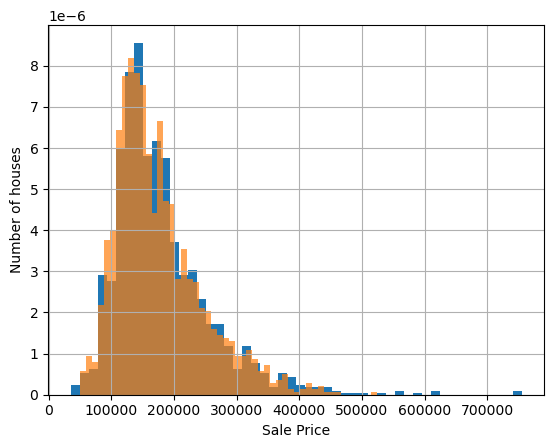

In [65]:
# histogran to evaluate target distribution

ax = train['SalePrice'].hist(bins=50, density=True)
test['SalePrice_pred'].hist(bins=50, density=True, ax=ax, alpha=0.7)
plt.ylabel('Number of houses');
plt.xlabel('Sale Price');